# Preparación del Dataset y Modelado\n## Attrition Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

with open('../data/attrition_dataset.pkl', 'rb') as f:
    df = pd.read_pickle('../data/attrition_dataset.pkl')

df = df.reset_index(drop=True)
print(f'Shape original: {df.shape}')

Shape original: (1426, 31)


## 1. Eliminación de Variables sin Aporte

Según el EDA, las siguientes variables se descartan:
- `EmployeeCount`, `StandardHours`, `Over18`: valor constante en todos los registros, sin variabilidad
- `EmployeeID`: identificador único, no predictivo

In [55]:
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeID']
df = df.drop(columns=cols_to_drop)
print(f'Shape luego de eliminar variables: {df.shape}')

Shape luego de eliminar variables: (1426, 27)


## 2. Feature Engineering

Se crean las 8 variables derivadas. Los NaN que puedan propagarse desde variables con nulos serán imputados en el paso siguiente, después del split.

In [57]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement']
df['satisfaction_index']    = df[sat_cols].mean(axis=1)
df['company_tenure_ratio']  = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['promotion_stagnation']  = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['manager_loyalty_ratio'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)
df['experience_density']    = df['TotalWorkingYears'] / (df['Age'] - 17)
df['overwork_pressure']     = df['hrs'] / (df['WorkLifeBalance'] + 0.5)
df['anchoring_score']       = df[['YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager']].mean(axis=1)

avg_income_by_level = df.groupby('JobLevel')['MonthlyIncome'].transform('mean')
df['income_vs_level'] = (df['MonthlyIncome'] - avg_income_by_level) / avg_income_by_level

print(f'Shape luego de feature engineering: {df.shape}')
print(f'Features creadas: satisfaction_index, company_tenure_ratio, promotion_stagnation,')
print(f'                  manager_loyalty_ratio, experience_density, overwork_pressure,')
print(f'                  anchoring_score, income_vs_level')

Shape luego de feature engineering: (1426, 35)
Features creadas: satisfaction_index, company_tenure_ratio, promotion_stagnation,
                  manager_loyalty_ratio, experience_density, overwork_pressure,
                  anchoring_score, income_vs_level


## 3. Separar X e y

In [ ]:
X = df.drop(columns='Attrition')
y = (df['Attrition'] == 'Yes').astype(int)

print(f'X shape: {X.shape}  |  Nulos en X: {X.isnull().sum().sum()}')
print(f'y shape: {y.shape}')

## 4. Train/Test Split

Se divide primero, **antes de imputar y encodear**, para evitar data leakage. La mediana y el encoding se calcularán solo con los datos de train y luego se aplicarán al test.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

## 5. Imputación (fit solo en train)

Se calcula la mediana y la moda **únicamente con X_train**, luego se aplica al test. Así el test no influye en los valores de imputación.

In [ ]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Calcular estadísticos solo del train
medianas = X_train[num_cols].median()
modas    = {col: X_train[col].mode()[0] for col in cat_cols if X_train[col].isnull().any()}

# Imputar train
X_train = X_train.copy()
X_train[num_cols] = X_train[num_cols].fillna(medianas)
for col, moda in modas.items():
    X_train[col] = X_train[col].fillna(moda)

# Imputar test con los mismos valores del train
X_test = X_test.copy()
X_test[num_cols] = X_test[num_cols].fillna(medianas)
for col, moda in modas.items():
    X_test[col] = X_test[col].fillna(moda)

print(f'Nulos en X_train: {X_train.isnull().sum().sum()}')
print(f'Nulos en X_test:  {X_test.isnull().sum().sum()}')

## 6. Encoding (fit solo en train)

Se usa `OneHotEncoder` de sklearn con `fit` en train y `transform` en ambos. Así las categorías aprendidas son solo las del train.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[cat_cols_to_encode])

enc_cols = encoder.get_feature_names_out(cat_cols_to_encode)

X_train_enc = pd.DataFrame(encoder.transform(X_train[cat_cols_to_encode]), columns=enc_cols, index=X_train.index)
X_test_enc  = pd.DataFrame(encoder.transform(X_test[cat_cols_to_encode]),  columns=enc_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols_to_encode), X_train_enc], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_cols_to_encode),  X_test_enc],  axis=1)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

## Modelos

### 2.0 Regresión Logística

La regresión logística es el punto de partida natural para un problema de clasificación binaria. Es un modelo lineal, simple e interpretable que estima la probabilidad de que un empleado se vaya usando una función sigmoide.

Se usa como **modelo base de referencia** antes de pasar a modelos más complejos. Si un modelo más complejo no supera significativamente a la regresión logística, la simplicidad e interpretabilidad de esta última la hacen preferible.

Accuracy: 0.7448
AUC-ROC:  0.8150

Classification Report:
              precision    recall  f1-score   support

          No       0.74      0.76      0.75       143
         Yes       0.75      0.73      0.74       143

    accuracy                           0.74       286
   macro avg       0.75      0.74      0.74       286
weighted avg       0.75      0.74      0.74       286



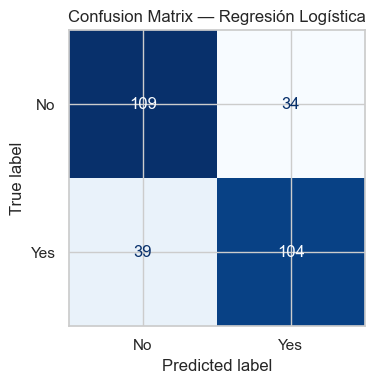

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f'Accuracy: {acc_lr:.4f}')
print(f'AUC-ROC:  {auc_lr:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_lr, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Regresión Logística')
plt.tight_layout()
plt.show()

### 2.1 XGBoost Base

Se entrena un XGBoost con parámetros por defecto como línea de base.

Accuracy: 0.9371
AUC-ROC:  0.9785

Classification Report:
              precision    recall  f1-score   support

          No       0.99      0.88      0.93       143
         Yes       0.89      0.99      0.94       143

    accuracy                           0.94       286
   macro avg       0.94      0.94      0.94       286
weighted avg       0.94      0.94      0.94       286



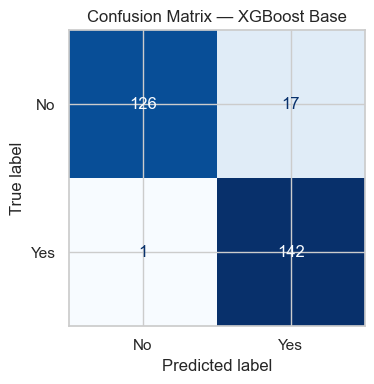

In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

y_pred = xgb_base.predict(X_test)
y_prob = xgb_base.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {acc:.4f}')
print(f'AUC-ROC:  {auc:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost Base')
plt.tight_layout()
plt.show()

In [63]:
y_pred_train = xgb_base.predict(X_train)
y_prob_train = xgb_base.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_prob_train)

print('           Train     Test')
print(f'Accuracy:  {acc_train:.4f}   {acc:.4f}')
print(f'AUC-ROC:   {auc_train:.4f}   {auc:.4f}')
print(f'\nDiferencia Accuracy: {acc_train - acc:.4f}')
print(f'Diferencia AUC-ROC:  {auc_train - auc:.4f}')

           Train     Test
Accuracy:  1.0000   0.9371
AUC-ROC:   1.0000   0.9785

Diferencia Accuracy: 0.0629
Diferencia AUC-ROC:  0.0215


### 2.2 XGBoost — Tuning de Hiperparámetros (Optuna)

El modelo base mostró overfitting (train=1.0, test=0.937). Se usa **Optuna** para optimizar los hiperparámetros. A diferencia de GridSearchCV que prueba todas las combinaciones posibles, Optuna usa optimización bayesiana (TPE — Tree-structured Parzen Estimator): aprende de cada trial anterior y enfoca la búsqueda en las zonas del espacio que mostraron mejores resultados, siendo significativamente más eficiente.

Se maximiza el AUC-ROC con 5-fold cross-validation.

In [64]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3.0),
    }
    model = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'Mejor AUC-ROC (CV): {study.best_value:.4f}')
print(f'Mejores hiperparámetros:\n{study.best_params}')

ModuleNotFoundError: No module named 'optuna'

In [ ]:
best_xgb = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
best_xgb.fit(X_train, y_train)

y_pred_tuned       = best_xgb.predict(X_test)
y_prob_tuned       = best_xgb.predict_proba(X_test)[:, 1]
y_pred_tuned_train = best_xgb.predict(X_train)

acc_tuned       = accuracy_score(y_test, y_pred_tuned)
auc_tuned       = roc_auc_score(y_test, y_prob_tuned)
acc_tuned_train = accuracy_score(y_train, y_pred_tuned_train)

print('Comparación Base vs Tuned:')
print(f'{"":25} {"Base":>8} {"Tuned":>8}')
print(f'{"Accuracy (test)":25} {acc:.4f}   {acc_tuned:.4f}')
print(f'{"AUC-ROC (test)":25} {auc:.4f}   {auc_tuned:.4f}')
print(f'{"Accuracy (train)":25} {1.0:.4f}   {acc_tuned_train:.4f}')
print(f'\nClassification Report — XGBoost Tuned:\n{classification_report(y_test, y_pred_tuned, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost Tuned')
plt.tight_layout()
plt.show()

## 3. Evaluación Final — Cross-Validation con Pipeline

Se evalúa el mejor modelo (XGBoost con parámetros de Optuna) usando **5-fold stratified cross-validation** con un Pipeline completo.

El Pipeline garantiza que en cada fold la imputación y el encoding se calculen **solo con el train del fold**, sin data leakage. Se usa `X` crudo (con nulos y categóricas) para que el Pipeline maneje todo internamente.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate

num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

num_transformer = SimpleImputer(strategy='median')

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(pipeline, X, y, cv=cv,
                             scoring=['accuracy', 'roc_auc'],
                             return_train_score=True)

print('Resultados 5-Fold Cross-Validation:')
print(f'{"":25} {"Media":>8} {"Std":>8}')
print(f'{"Accuracy (test)":25} {cv_results["test_accuracy"].mean():.4f}   {cv_results["test_accuracy"].std():.4f}')
print(f'{"AUC-ROC (test)":25} {cv_results["test_roc_auc"].mean():.4f}   {cv_results["test_roc_auc"].std():.4f}')
print(f'{"Accuracy (train)":25} {cv_results["train_accuracy"].mean():.4f}   {cv_results["train_accuracy"].std():.4f}')
print(f'{"AUC-ROC (train)":25} {cv_results["train_roc_auc"].mean():.4f}   {cv_results["train_roc_auc"].std():.4f}')

print(f'\nScores por fold (AUC-ROC test): {cv_results["test_roc_auc"].round(4)}')